In [107]:
# Your Details

Your Name: Aashrith Sai Yamsani

Your ID Number: 25287419

# Etivity 3 - Task 2: Use Tensorflow and Keras to build a model for sign-language digit classification using transfer learning based on the MobileNet CNN model and then do fine-tuning.

In the previous task you developed and used CNN models using TensorFlow Keras libraries. In this notebook you will carry out transfer learning by modifying the MobileNet model [1] trained on the ImageNet [2] database and then perform fine-tuning to try and imporve the performance. 


By the end of this notebook, you'll be able to: 

* Load a pre-trained MobileNet model using the TensorFlow/Keras framework.
* Replace the last layer from 1000 nodes down to 10 nodes for sign-language digit classification.
* Modify the trainable parameters to false except for the last layer.
* Fit the model to the training set.
* Analyse the model perfromance.
* Perform fine-tuning by making more layer parameters trainable and retrain the model.
* Analyse the fine-tuned model performance.
* Store your model architecture.


### Important Note 1 on Submission 

There are code exercises to complete in this task. Use the notes provided to help you build understanding. Insert your code entries into the cell areas marked with the 'enter code here' text as below, so that grading can easily be assessed.

\### **ENTER CODE HERE**

Please make sure you are not doing the following:

1. You have not added any _extra_ `print` statement(s) in the assignment.
2. You have not added any _extra_ code cell(s) in the assignment.
3. You have not changed any of the function parameters.
4. You are not using any global variables inside your graded exercises. Unless specifically instructed to do so, please refrain from it and use the local variables instead.
5. You are not changing the assignment code where it is not required, like creating _extra_ variables.

### Important Note 2 on Submission 

Where indicated, <font color='red'>**ENTER COMMENTS HERE**</font>, make sure to read the question carefully and include **YOUR OWN** analysis and observations in the text markdown cell provided.

### Let's get started!

## Table of Contents
- [1- Packages and Dataset](#1)
    - [1.1 - Prepare and load dataset](#1-1)
- [2 - Apply Transfer Learning  on the MobileNet CNN model](#2)
    - [2.1 - Import the MobileNet model](#2-1)
    - [2.2 - Modify the MobileNet model for sign-digit classification](#2-2)
- [3 - Compile and train the MobileNet model for sign-language digit classification](#3)
- [4 - Analyse model performance](#4)
    - [4.1 - Plot the model loss and accuracy metrics](#4-1)
    - [4.2 - Generate the predictions and plot the confusion matrix](#4-2)
- [5 - Let's do some fine-tuning](#5)
    - [5.1 - Make all the model layers trainable](#5-1)
    - [5.2 - Fine-tune from a suitable layer](#5-2)
    - [5.2 - Compile and train the model](#5-3)
- [6 - Analyse model performance](#6)
    - [6.1 - Plot the model loss and accuracy metrics](#6-1)
    - [6.2 - Generate the predictions and plot the confusion matrix](#6-2)
    - [6.3 - Results analysis - commentary](#6-3)
- [7 - Save the model and weights](#7)

<a name='1'></a>
## 1- Packages and Dataset

In [108]:
import os
import shutil
import random
import glob
import matplotlib.pyplot as plt
import numpy as np
import itertools
import tensorflow as tf
import time
from keras_cnn_app_utils import *
            
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dense, Flatten, BatchNormalization, Conv2D, MaxPool2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix

# Measure time taken
def hms_string(sec_elapsed):
    h = int(sec_elapsed / (60 * 60))
    m = int((sec_elapsed % (60 * 60)) / 60)
    s = sec_elapsed % 60
    return f"{h}:{m:>02}:{s:>05.2f}"

**Use this code cell only if you have a GPU**

In [109]:
print("Is there a GPU available: "),
print(tf.config.experimental.list_physical_devices("GPU"))
physical_devices = tf.config.experimental.list_physical_devices('GPU')
print("Num GPUs Available: ", len(physical_devices))

Is there a GPU available: 
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Num GPUs Available:  1


<a name='1-1'></a>
### 1.1 Prepare and load dataset

For this exericise, we will use a sign-language digit dataset that was created by high-school students [3]. The dataset consist of example images as seen in Figure 1 representing the sign-language for digits from 0 to 9.

<center><img src="images/Sign-Digits_dataset_preview.png" style="width:650px;height:300px;"></center>
<caption><center> <b>Figure 1</b>: <b>Example sign-language images representing digits 0-9.</b><br></center></caption>
 
**Details of dataset:**
   * Image size: 100 x 100 pixels
   * Color space: RGB
   * Number of classes: 10 (Digits: 0-9)
   * Number of images: 2062
   
   
**Note**: As all of the images are contained within a single 'dataset' folder, we first have to create separate train/valid/test sets using the cell below. 

In [110]:
# Create train, valid and test image sets within the Sign Language Dataset directory
os.chdir('./Sign-Language-Digits-Dataset')
if os.path.isdir('train') is False:
    os.makedirs('train')
if os.path.isdir('valid') is False:
    os.makedirs('valid')
if os.path.isdir('test') is False:
    os.makedirs('test')

# Move all class folder images from Dataset into train folder
if os.path.isdir('train/0') is False:
    for j in range(0,10):
        shutil.move('Dataset/'+ str(j), 'train/')  

# Make class folders for the valid data set
if os.path.isdir('valid/0') is False:
    os.chdir('valid')
    for j in range(0,10):
         os.makedirs(str(j))
    os.chdir('../')
    
# Make class folders for the test data set
if os.path.isdir('test/0') is False:
    os.chdir('test')
    for j in range(0,10):
         os.makedirs(str(j))
    os.chdir('../')

# Create valid and test data sets by randomly taking samples from the train set
if not glob.glob('./valid/0/IMG_*.jpg'):
    os.chdir('train')
    for j in range(0,10):
        os.chdir(str(j))
        for i in random.sample(glob.glob('*'), 30):
            shutil.move(i, '../../valid/'+str(j))
        for i in random.sample(glob.glob('*'), 5):
            shutil.move(i, '../../test/'+str(j))
        os.chdir('../')
    os.chdir('../')
os.chdir('../')
#  Make sure we are in the current notebook home directory
os.getcwd()

'C:\\Users\\25287419\\EE6008\\Etivity3\\Task2'

In [111]:
train_path = 'Sign-Language-Digits-Dataset/train'
valid_path = 'Sign-Language-Digits-Dataset/valid'
test_path = 'Sign-Language-Digits-Dataset/test'

**Preprocess images based on mobilenet and use TensorFlow's ImageDataGenerator to organise images into batch sizes of 10**

In [112]:
train_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet.preprocess_input) \
    .flow_from_directory(directory=train_path, target_size=(224,224), batch_size=10)
valid_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet.preprocess_input) \
    .flow_from_directory(directory=valid_path, target_size=(224,224), batch_size=10)
test_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet.preprocess_input) \
    .flow_from_directory(directory=test_path, target_size=(224,224), batch_size=10, shuffle=False)

Found 1712 images belonging to 10 classes.
Found 300 images belonging to 10 classes.
Found 50 images belonging to 10 classes.


In [113]:
assert train_batches.n == 1712
assert valid_batches.n == 300
assert test_batches.n == 50
assert train_batches.num_classes == valid_batches.num_classes == test_batches.num_classes == 10

**Let's look at some of the images in the train dataset**

In [114]:
# Grab the images and labels from the training batch (10)
imgs, labels = next(train_batches)

In [115]:
# This function plots images in the form of a grid with 1 row and 10 colummns (from tensorflow site)
def plotImages(images_arr):
    fig, axes = plt.subplots(1, 10, figsize=(20,20))
    axes = axes.flatten()
    for img, ax in zip( images_arr, axes):
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.6862745].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.94509804].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with R

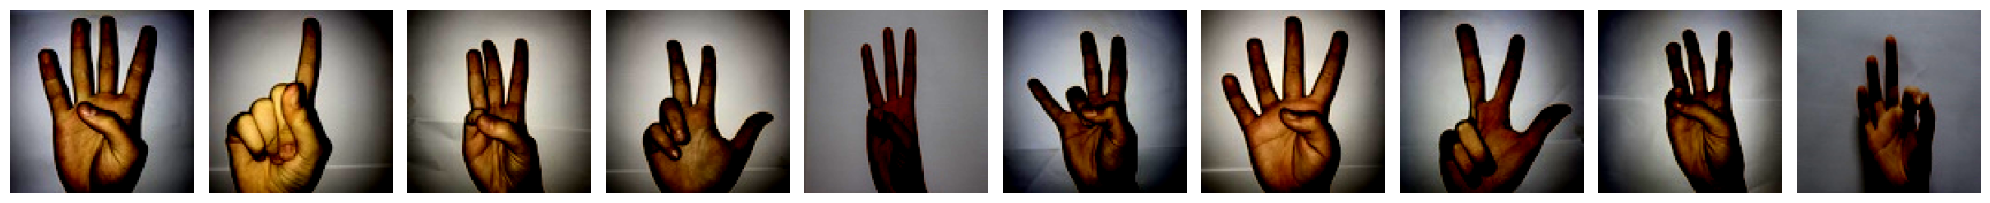

[[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


In [116]:
plotImages(imgs)
print(labels)

<a name='2'></a>
## 2 - Apply Transfer Learning  on the MobileNet CNN model

<a name='2-1'></a>
### 2.1 Import the MobileNet CNN model and report on the model structure

1. Import the MobileNet model from Keras. Note, an internet connection is needed to download this model.
2. Report on the model.summary().
3. Report on the model type - notice that this is a functional model.
4. Check how many layers in this model.

In [117]:
mobilenet = tf.keras.applications.mobilenet.MobileNet() # Using pre trained MobileNet model from tf.keras

In [118]:
mobilenet.summary()

Model: "mobilenet_1.00_224"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 112, 112, 32)      864       
                                                                 
 conv1_bn (BatchNormalizatio  (None, 112, 112, 32)     128       
 n)                                                              
                                                                 
 conv1_relu (ReLU)           (None, 112, 112, 32)      0         
                                                                 
 conv_dw_1 (DepthwiseConv2D)  (None, 112, 112, 32)     288       
                                                                 
 conv_dw_1_bn (BatchNormaliz  (None, 112, 112, 32)     128       
 ation)                                         

In [119]:
type(mobilenet) #Used for check the model type.

keras.engine.functional.Functional

In [120]:
len(mobilenet.layers) #Showing the no of layers inn the model

91

<a name='2-2'></a>
### 2.2 Modify the MobileNet  model for sign-digit classification and report on the model structure

This is a functional API Keras model for ImageNet classification (1000 classes). We need 10 class outputs for our sign-language digit classification and so need to build a new model using the same layers as in MobileNet upto the last layer.

1. (a) Create a new  model thats uses the MobileNet model upto to the last layer. (b) Add a final layer with 10 units using a softmax activation (c) Show the new model structure.
2. (a) Make all the layers upto the final layer not trainable and (b) Show the model structure that gives the number of trainable weights.

In [121]:
### ENTER CODE HERE
# 1(a): Create a model that uses all the layers in the MobileNet model except for the last layer. 
# 1(b): Add a new final layer that has 10 units and a softmax activation.
# 1(c): Report on the model structure.

#Remove the original mobilenet classification layer
x = mobilenet.layers[-2].output
#new Dense layer with 10 outputs 
output = Dense(units=10, activation='softmax')(x)
#Create the new transfer learning model
model = tf.keras.models.Model(inputs=mobilenet.input, outputs=output)
# Display the structure of the modified model
model.summary()


Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 112, 112, 32)      864       
                                                                 
 conv1_bn (BatchNormalizatio  (None, 112, 112, 32)     128       
 n)                                                              
                                                                 
 conv1_relu (ReLU)           (None, 112, 112, 32)      0         
                                                                 
 conv_dw_1 (DepthwiseConv2D)  (None, 112, 112, 32)     288       
                                                                 
 conv_dw_1_bn (BatchNormaliz  (None, 112, 112, 32)     128       
 ation)                                                    

In [122]:
### ENTER CODE HERE 
# 2(a): Make all layers not trainable
# 2(b): Report on model structure - showing the number of trainable parameters

# Freeze all layers of the base MobileNet model so that their weights are not updated
for layer in  model.layers[:-1]:
    layer.trainable = False
# Ensure the final classification layer remains trainable
model.layers[-1].trainable = True
# Show the updated model structure
model.summary()


Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 112, 112, 32)      864       
                                                                 
 conv1_bn (BatchNormalizatio  (None, 112, 112, 32)     128       
 n)                                                              
                                                                 
 conv1_relu (ReLU)           (None, 112, 112, 32)      0         
                                                                 
 conv_dw_1 (DepthwiseConv2D)  (None, 112, 112, 32)     288       
                                                                 
 conv_dw_1_bn (BatchNormaliz  (None, 112, 112, 32)     128       
 ation)                                                    

<a name='3'></a>
## 3 - Train the MobileNet model for sign-language digit classification

###  Compile the CNN model and train the network

1. Use **model.compile()** to compile the CNN model using Adam optimization and a learning_rate = 0.0001. Also specify categorical_crossentropy as the loss function and report on the accuracy metric.


2. Use **history=model.fit()** with inputs 'x=train_batches' and 'steps_per_epoch=len(train_batches)'. Also set 'validation_data=valid_batches' as input, so that you can investigate the valid set loss/accuracy figure. This will be useful in determining the performance of this model. Use 10 epochs to initially train the network.

In [123]:
### ENTER CODE HERE (compile the model)
model.compile( optimizer=Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])
# Compile the transfer learning model
# Adam optimizer is used for efficient training
# Categorical crossentropy is suitable for multi-class classification

In [124]:
### ENTER CODE HERE (train the model)
# If you want to use the GPU to train the model quicker - insert this line before the training - "with tf.device('/GPU:0'):"
history = model.fit(x=train_batches,steps_per_epoch=len(train_batches),validation_data=valid_batches,validation_steps=len(valid_batches),epochs=10,verbose=2)
# Train the model using the training dataset
# steps_per_epoch defines how many batches are used in each epoch

Epoch 1/10
172/172 - 7s - loss: 2.6932 - accuracy: 0.2407 - val_loss: 1.8511 - val_accuracy: 0.3667 - 7s/epoch - 43ms/step
Epoch 2/10
172/172 - 5s - loss: 1.5347 - accuracy: 0.4696 - val_loss: 1.2443 - val_accuracy: 0.5567 - 5s/epoch - 27ms/step
Epoch 3/10
172/172 - 5s - loss: 1.0688 - accuracy: 0.6209 - val_loss: 1.0241 - val_accuracy: 0.6400 - 5s/epoch - 28ms/step
Epoch 4/10
172/172 - 6s - loss: 0.8345 - accuracy: 0.7185 - val_loss: 0.8280 - val_accuracy: 0.7033 - 6s/epoch - 34ms/step
Epoch 5/10
172/172 - 5s - loss: 0.6744 - accuracy: 0.7704 - val_loss: 0.6709 - val_accuracy: 0.7833 - 5s/epoch - 31ms/step
Epoch 6/10
172/172 - 6s - loss: 0.5687 - accuracy: 0.8119 - val_loss: 0.5999 - val_accuracy: 0.8033 - 6s/epoch - 33ms/step
Epoch 7/10
172/172 - 6s - loss: 0.4907 - accuracy: 0.8470 - val_loss: 0.5377 - val_accuracy: 0.8133 - 6s/epoch - 33ms/step
Epoch 8/10
172/172 - 5s - loss: 0.4381 - accuracy: 0.8651 - val_loss: 0.5137 - val_accuracy: 0.8333 - 5s/epoch - 29ms/step
Epoch 9/10
172/1

<a name='4'></a>
## 4 - Analyse model performance: Loss, accuracy, predictions and confusion matrix

<a name='4-1'></a>
### 4.1 **Plot** the model loss and accuracy metrics in the code cell below

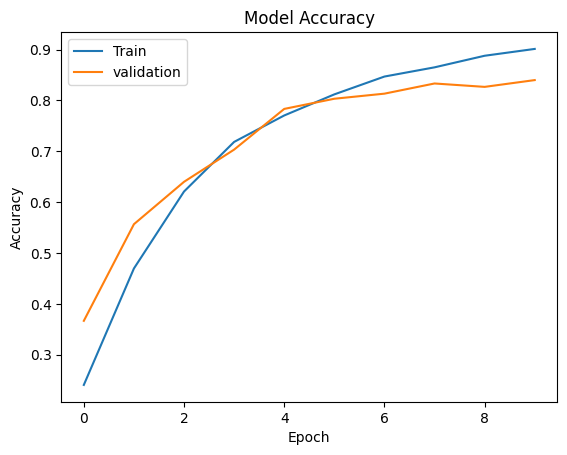

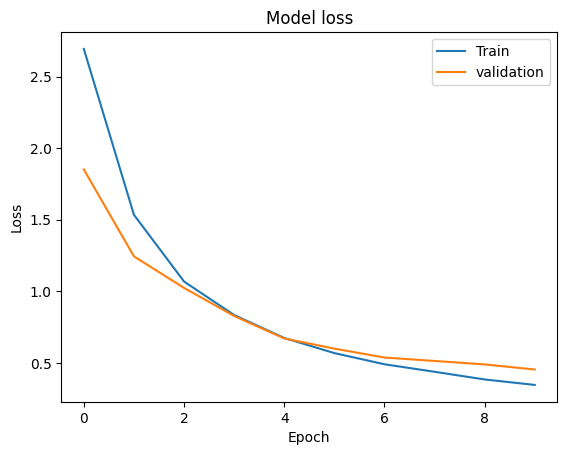

In [125]:
### ENTER CODE HERE
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','validation'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','validation'])
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()


**What** do these plots reveal about the model performance?
**Enter your own observations in the markdown cell**

### <span style='color: red;'>ENTER COMMENTS HERE</span> ###


From the accuracy graph we can see that the model improves steadily during training. The training accuracy starts at around 24% in the first epoch and then gradually increases to 90% by epoch 10.

At the same time, the validation accuracy also increases from about 36% to around 84%, which shows that the model is learning useful features from the dataset.

The loss graph also shows a consistent decrease for both training and validation loss as the epochs are increasing. This indicates that the model is learning the patterns in the data and improving its predictions .

Overall, the results suggest that the MobileNet transfer learning model is performing well on the sign language digit dataset. The model does not appear to be more overfitting since the validation accuracy follows a similar trend to the training accuracy.

<a name='4-2'></a>
### 4.2 Generate the predictions and plot the confusion matrix

1. Generate the predictions by using the **model.predict()** function call on the test_batches dataset.

In [126]:
### ENTER CODE HERE
# Generating the predictions on the test dataset using the trained model
predictions = model.predict(x=test_batches, steps=len(test_batches), verbose=0)
#Convert the prob outputs into predicted class
predicted_classes = np.argmax(predictions, axis=1)

2. Plot the performance of the predictions usign a **confusion matrix**. Use the sklearn.metrics confusion_matrix() command with the test_batches correct predictions and predictions from the trained model as inputs. Plot the confusion matrix by labeling the plot correctly and analyse the result - what does this plot inform you about the level of model performance?
**Note**: You can use the plot_confusion_matrix() routine in the keras_cnn_app_utils.py file.

Confusion matrix, without normalization
[[5 0 0 0 0 0 0 0 0 0]
 [0 5 0 0 0 0 0 0 0 0]
 [0 1 2 0 0 0 1 1 0 0]
 [0 0 0 5 0 0 0 0 0 0]
 [0 0 0 0 4 0 1 0 0 0]
 [0 0 0 0 0 5 0 0 0 0]
 [0 0 0 0 0 0 5 0 0 0]
 [0 0 0 0 0 0 1 3 1 0]
 [0 0 0 0 0 0 0 1 3 1]
 [0 0 0 0 0 0 0 0 1 4]]


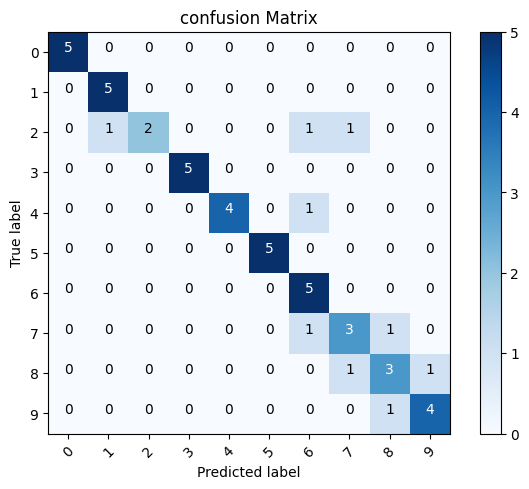

In [127]:
### ENTER CODE HERE
true_classes = test_batches.classes  # Used for getting the true labels of test dataset
class_labels = list(test_batches.class_indices.keys()) # Get the label names
cm = confusion_matrix(true_classes, predicted_classes) # Computing the confusion matrix to evaluate model performance.
plot_confusion_matrix(cm=cm, classes=class_labels, title='confusion Matrix') # Plot the matrix


**What story does the confusion matrix tell?** - Place your commentary on the confusion matrix in the markdown cell below.

### <span style='color: red;'>ENTER COMMENTS HERE</span> ###


The confusion matrix shows how well the model predicts each digit class. Most of the values are on the diagonal of the matrix, which indicates that the model correctly classified many of the sign-language digit images.

Several classes such as 0, 1, 3, 5, and 6 were predicted correctly for all test samples .BUt there are few misclassifications between some digits. For example, digit 2 was sometimes predicted as other digits, and digits 7, 8, and 9 also show a few incorrect predictions. hese mistakes may occur because some hand gestures for these digits look visually similar or have small differences that the model may struggle to distinguish.

Overall, the confusion matrix shows that the model performs good but still has some dificulty in distinguishing between certain digits before fine tuning. This indicates that further training or fine tuning of the deeper layers may help to improve the models ability to detect more detailed features.


<a name='5'></a>
## 5 - Let's do some fine-tuning

Fine-tuning refers to using the weights of an already trained network as the starting values for training a new network:

<a name='5-1'></a>
### 5.1 Make all the model layers trainable
First, lets make all the model layers completely trainable and print out the number of layers in this base model.

In [128]:
model.trainable = True
# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(model.layers))  

Number of layers in the base model:  91


<a name='5-2'></a>
### 5.2 Fine-tune starting from a suitable layer

As there are 91 layers in this model, we will decide to fine-tune the network from layer 80 onwards. In order to do this you will need to freeze all the layer parameters (weights + biases) up to and including layer 80 so as not to make them trainable.

**Hint**: Use 'layer.trainable = False'

This will allow us to retrain only the final 11 layers in the CNN model.

In [129]:
### ENTER CODE HERE

# Freeze the first 80 layers of the model
for layer in model.layers[:80]:
    layer.trainable = False
# Allow the deeper layers to train
for layer in model.layers[80:]:
    layer.trainable = True

<a name='5-3'></a>
### 5.3  Compile the model and train the network

1. Use **model.compile()** to compile the CNN model using Adam optimization and a learning_rate = 0.0001. Also specify categorical_crossentropy as the loss function and report on the accuracy metric.


2. Use **history_fine=model.fit()** with the same command inputs as previously, except to train the model for a further 5 epochs resuming from the last trained model epoch point.

    **Hint**: Use "history_fine = model.fit(,...,epochs=15,initial_epoch=history.epoch[-1],verbose=2)"

In [130]:
### ENTER CODE HERE
# 1. Compile the model
# 2. Train the model

# Compile the model again before fine-tuning
model.compile(optimizer=Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

# Continue training from the previous training stage from 10th epoch
history_fine = model.fit(x=train_batches,steps_per_epoch=len(train_batches),validation_data=valid_batches,validation_steps=len(valid_batches),epochs=15,initial_epoch=history.epoch[-1],verbose=2)

Epoch 10/15
172/172 - 7s - loss: 0.5609 - accuracy: 0.8166 - val_loss: 0.4151 - val_accuracy: 0.8833 - 7s/epoch - 42ms/step
Epoch 11/15
172/172 - 5s - loss: 0.1568 - accuracy: 0.9474 - val_loss: 0.3007 - val_accuracy: 0.9133 - 5s/epoch - 32ms/step
Epoch 12/15
172/172 - 6s - loss: 0.0856 - accuracy: 0.9743 - val_loss: 0.2575 - val_accuracy: 0.9333 - 6s/epoch - 35ms/step
Epoch 13/15
172/172 - 4s - loss: 0.0459 - accuracy: 0.9836 - val_loss: 0.2696 - val_accuracy: 0.9233 - 4s/epoch - 25ms/step
Epoch 14/15
172/172 - 5s - loss: 0.0348 - accuracy: 0.9918 - val_loss: 0.1931 - val_accuracy: 0.9433 - 5s/epoch - 30ms/step
Epoch 15/15
172/172 - 6s - loss: 0.0207 - accuracy: 0.9947 - val_loss: 0.2025 - val_accuracy: 0.9500 - 6s/epoch - 37ms/step


<a name='6'></a>
## 6 - Analyse the fine-tuned model performance: Loss, predictions and confusion matrix

<a name='6-1'></a>
### 6.1 Plot the model loss and accuracies.
It should be possible to merge the loss/accuracy performance from the histories of the models that was first trained over 10 epochs and then further fine-tuned by a further 5 epochs.

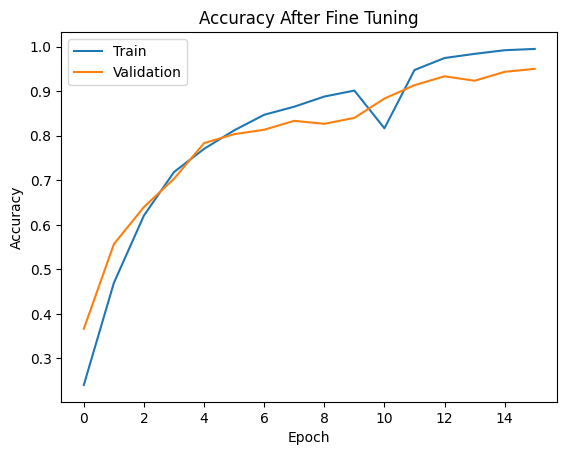

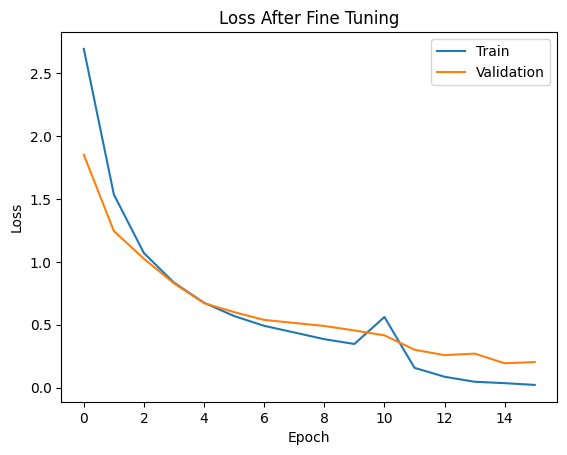

In [131]:
### ENTER CODE HERE
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

epochs_range = range(len(acc))

plt.plot(epochs_range, acc)
plt.plot(epochs_range, val_acc)
plt.title('Accuracy After Fine Tuning')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])
plt.show()

plt.plot(epochs_range, loss)
plt.plot(epochs_range, val_loss)
plt.title('Loss After Fine Tuning')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])
plt.show()


<a name='6-2'></a>
### 6.2 Generate the predictions and plot the confusion matrix

Confusion matrix, without normalization
[[5 0 0 0 0 0 0 0 0 0]
 [0 5 0 0 0 0 0 0 0 0]
 [0 0 5 0 0 0 0 0 0 0]
 [0 0 0 5 0 0 0 0 0 0]
 [0 0 0 0 5 0 0 0 0 0]
 [0 0 0 0 0 5 0 0 0 0]
 [0 0 0 0 0 0 5 0 0 0]
 [0 0 0 0 0 0 0 5 0 0]
 [0 0 0 0 0 0 0 0 5 0]
 [0 0 0 0 0 0 0 0 0 5]]


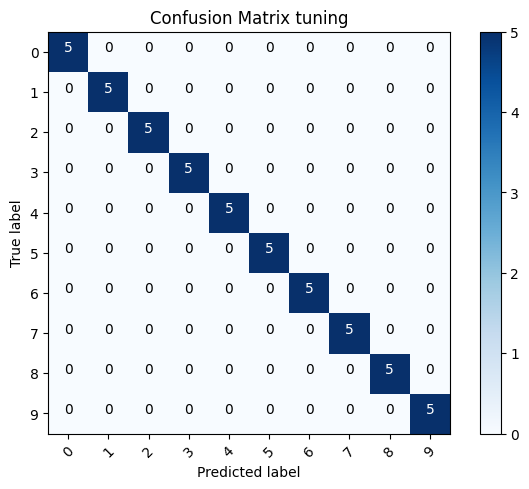

In [132]:
### ENTER CODE HERE
# 1. Generate the predictions
# 2. Plot the confusion matrix (from sklearn.metrics)

# Generate predictions using the fine tuned model
predictions_fine = model.predict(x=test_batches, steps=len(test_batches), verbose=0)

# Convert prediction probabilities into class labels
predicted_classes_fine = np.argmax(predictions_fine, axis=1)

#Compute confusion matrix for fine tuned model
cm_fine = confusion_matrix(test_batches.classes, predicted_classes_fine)

#Ploting confusion matrix
plot_confusion_matrix(cm=cm_fine, classes=class_labels, title='Confusion Matrix tuning')

<a name='6-3'></a>
### 6.3 Results analysis - commentary

**What do the above plots tell you about the fine-tuned model performance** - Place your commentary in the markdown cell below. What steps can you do to make the model perform better? (**show a code implementation** by including an extra code cell before Section 7 - Save model)

### <span style='color: red;'>ENTER COMMENTS HERE</span> ###


After Fine tuning the model ,the confusion matrix shows that the model correctly classified all the test images for each digit class.All the values appear along the diagonal of the matrix, which indicates that the predictions perfectly match the true labels . Each class from 0 to 9 has 5 correct predictions, giving a total of 50 correct classifications out of 50 test images. 

The accuracy graph shows that the training accuracy increases close to 99%, while the validation accuracy reaches around 95%. This indicates that allowing the deeper layers of the network to learn from the dataset helped the model capture more detailed features of the sign-language digits.

This means the fine tuned mobilenet model acheived 100% accuracy on the test dataset. Compared to earlier confusion matrix before tuning. the model performance has clearly improved. 

Fine-tuning helped improve the model because more layers of the pretrained MobileNet network were allowed to update their weights during training. This allowed the model to better adapt the learned ImageNet features to the specific patterns of the sign-language digit dataset.

To further improve the model or making it to identify the images correctly, techniques such as data augmentation, adding more training images, or adjusting the learning rate could be used.

<a name='7'></a>
##  7 - Save model

In [133]:
# Check first to see if files already exists
# If not, the model and weights is saved to the disk
# Note model already contains the weights, but showing how it can done seprately
import os.path
if os.path.isfile('models/Sign_Language_Digits_MobNet_model.keras') is False:
    model.save('models/Sign_Language_Digits_MobNet_model.keras')
    
if os.path.isfile('models/Sign_Language_Digits_MobNet.weights.h5') is False:
    model.save_weights('models/Sign_Language_Digits_MobNet.weights.h5')

<font color='blue'>

**What you should remember**:

* To adapt the classifier to new data: Delete the top layer, add a new classification layer, and train only on that layer.
* Fine-tune the final layers of your model to capture high-level details near the end of the network and potentially improve accuracy.

## Congratulations!

You've completed this assignment on transfer learning and fine-tuning. Here's a quick recap of all you just accomplished:

* Created a dataset from a directory.
* Augmented data with the Sequential API.
* Adapted a pretrained model to new data with the Functional API and MobileNet.
* Fine-tuned the classifier's final layers and boosted the model's accuracy.

That's amazing! 

**References**:
- [1] MobileNet Paper: https://arxiv.org/pdf/1704.04861.pdf
- [2] ImageNet : http://www.image-net.org/
- [3] Sign-language Digits Dataset: https://github.com/ardamavi/Sign-Language-Digits-Dataset